In [1]:
!pip install tensorflow transformers

In [2]:
!pip install tf-keras

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import regularizers
from transformers import BertTokenizer, TFBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [5]:
from transformers import (
    # GPT2Tokenizer, TFGPT2ForSequenceClassification,
    RobertaTokenizer, TFRobertaForSequenceClassification
)

In [6]:
# Upload your dataset
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

Saving isear_processed_dataset.csv to isear_processed_dataset.csv


In [7]:
# Load CSV dataset
df = pd.read_csv(filename)

In [8]:
# Preprocess labels (if labels are strings like "happy", "sad")
le = LabelEncoder()
df["label"] = le.fit_transform(df["emotion"])  # Convert text labels to integers
num_classes = len(le.classes_)  # Number of emotion classes


In [9]:
# Split data into train, validation, and test sets
train_df, temp_df = train_test_split(df, test_size=0.25, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [10]:
# Extract texts and labels
train_texts, train_labels = train_df["cleaned_text"].tolist(), train_df["label"].values
val_texts, val_labels = val_df["cleaned_text"].tolist(), val_df["label"].values
test_texts, test_labels = test_df["cleaned_text"].tolist(), test_df["label"].values

In [11]:
df

,text,emotion,cleaned_text,label
0,"During the period of falling in love, each tim...",joy,during the period of falling in love each time...,4
1,When I was involved in a traffic accident.,fear,when i was involved in a traffic accident,2
2,When I was driving home after several days of...,anger,when i was driving home after several days of ...,0
3,When I lost the person who meant the most to me.,sadness,when i lost the person who meant the most to me,5
4,The time I knocked a deer down - the sight of ...,disgust,the time i knocked a deer down the sight of th...,1
...,...,...,...,...
7508,Two years back someone invited me to be the tu...,anger,two years back someone invited me to be the tu...,0
7509,I had taken the responsibility to do something...,sadness,i had taken the responsibility to do something...,5
7510,I was at home and I heard a loud sound of spit...,disgust,i was at home and i heard a loud sound of spit...,1
7511,I did not do the homework that the teacher had...,shame,i did not do the homework that the teacher had...,6


In [12]:
# Find max sentence length per row (based on word count)
def max_sentence_length(text):
    sentences = text.split('.')  # you can use nltk.sent_tokenize() for better results
    return max(len(sentence.split()) for sentence in sentences if sentence.strip())

df['max_sentence_length'] = df['cleaned_text'].apply(max_sentence_length)

# Find the row with the maximum sentence length
max_len_row = df.loc[df['max_sentence_length'].idxmax()]

# Print results
print("Maximum sentence length (in words):", max_len_row['max_sentence_length'])
print("Emotion label:", max_len_row['emotion'])
print("Text with longest sentence:\n", max_len_row['cleaned_text'])


Maximum sentence length (in words): 179
Emotion label: disgust
Text with longest sentence:
 a few days back i was waiting for the bus at the bus stop before getting into the bus i had prepared the exact amount of coins to pay for the bus fair and when i got into the bus i put these coins into the box meant to collect the bus fair i thought that i had paid and wanted to get inside however the bus driver called me and asked me in an impolite way if the coins were stuck at the opening of the box he had not seen me paying and there was not a stack of coins in the box i could not understand this and the driver kept questioning me he made me feel angry and at last i inserted a dollar coin in the box just to get away from him later i found that i had forgotten a few coins in my pocket and had not paid enough for the fair the first time after i had entered the bus i could still hear him scolding me and i felt disgusted


In [13]:
# RoBERTa Setup
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
roberta_model = TFRobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=num_classes
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

In [14]:
max_length = 179  # Adjust based on your text length
dropout_rate=0.25

In [15]:
# Tokenize for RoBERTa
def tokenize_roberta(texts):
    return roberta_tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="tf"
    )

In [16]:
batch_size=64

# Similarly create RoBERTa datasets
roberta_train_encodings = tokenize_roberta(train_texts)
roberta_val_encodings = tokenize_roberta(val_texts)
roberta_test_encodings = tokenize_roberta(test_texts)

roberta_train_dataset = tf.data.Dataset.from_tensor_slices((
    {"input_ids": roberta_train_encodings["input_ids"], "attention_mask": roberta_train_encodings["attention_mask"]},
    train_labels
)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

roberta_val_dataset = tf.data.Dataset.from_tensor_slices((
    {"input_ids": roberta_val_encodings["input_ids"], "attention_mask": roberta_val_encodings["attention_mask"]},
    val_labels
)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

roberta_test_dataset = tf.data.Dataset.from_tensor_slices((
    {"input_ids": roberta_test_encodings["input_ids"], "attention_mask": roberta_test_encodings["attention_mask"]},
    test_labels
)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [17]:
# import tensorflow as tf
from tensorflow.keras.optimizers import Adam
# from transformers import BertTokenizer, TFBertForSequenceClassification


In [18]:
from transformers import AdamWeightDecay
optimizer = AdamWeightDecay(learning_rate=2e-5)
roberta_model.compile(optimizer=optimizer, loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])


In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)


In [21]:
from sklearn.metrics import classification_report

# Initialize results dictionary
results = {}

In [22]:
# For custom models
train_data = roberta_train_dataset
val_data = roberta_val_dataset
test_data = roberta_test_dataset
optimizer = optimizer

In [23]:
# Train with EarlyStopping

print(f"\nTraining...")

his=roberta_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)



Training...
Epoch 1/10
89/89 [==============================] - 48s 293ms/step - loss: 1.5012 - accuracy: 0.4416 - val_loss: 0.9842 - val_accuracy: 0.6539
Epoch 2/10
89/89 [==============================] - 23s 258ms/step - loss: 0.8557 - accuracy: 0.7109 - val_loss: 0.8868 - val_accuracy: 0.7114
Epoch 3/10
89/89 [==============================] - 23s 258ms/step - loss: 0.6613 - accuracy: 0.7774 - val_loss: 0.8703 - val_accuracy: 0.7061
Epoch 4/10
89/89 [==============================] - 23s 257ms/step - loss: 0.5221 - accuracy: 0.8257 - val_loss: 0.9415 - val_accuracy: 0.7093
Epoch 5/10
89/89 [==============================] - 23s 257ms/step - loss: 0.4305 - accuracy: 0.8624 - val_loss: 0.9228 - val_accuracy: 0.7263
Epoch 6/10
89/89 [==============================] - 23s 257ms/step - loss: 0.3356 - accuracy: 0.8962 - val_loss: 1.0410 - val_accuracy: 0.7039
Epoch 7/10
89/89 [==============================] - 23s 257ms/step - loss: 0.2685 - accuracy: 0.9123 - val_loss: 1.1103 - val_acc

In [24]:
print(f"\nEvaluating...")
roberta_output=roberta_model.evaluate(test_data)


Evaluating...
15/15 [==============================] - 1s 88ms/step - loss: 1.2410 - accuracy: 0.7011


In [ ]:
# tf.keras.backend.clear_session()


In [25]:
roberta_output = roberta_model.predict(test_data)
y_pred = roberta_output.logits
y_pred = np.argmax(y_pred, axis=1)

15/15 [==============================] - 4s 86ms/step


In [26]:
# from tensorflow.python.framework.errors_impl import ResourceExhaustedError

# # Evaluation
# print(f"\nPredicting...")
# try:
#     # Try with smaller batch size and truncate sequences
#     gpt_output = gpt_model.predict(test_data, batch_size=4)  # Reduced from 8 to 4
#     y_pred = gpt_output.logits
#     y_pred = np.argmax(y_pred, axis=1)
# except ResourceExhaustedError:
#     # Fallback to CPU with even smaller batch size
#     print("GPU OOM, falling back to CPU...")
#     with tf.device('/CPU:0'):
#         gpt_output = gpt_model.predict(test_data, batch_size=2)  # Very small batch size
#         y_pred = gpt_output.logits
#         y_pred = np.argmax(y_pred, axis=1)

In [27]:
report = classification_report(test_labels, y_pred, output_dict=True)


In [34]:
# test_labels_np = test_labels.numpy()


In [29]:
report

{'0': {'precision': 0.5736434108527132,
  'recall': 0.6065573770491803,
  'f1-score': 0.5896414342629482,
  'support': 122.0},
 '1': {'precision': 0.6176470588235294,
  'recall': 0.7894736842105263,
  'f1-score': 0.693069306930693,
  'support': 133.0},
 '2': {'precision': 0.873015873015873,
  'recall': 0.7586206896551724,
  'f1-score': 0.8118081180811808,
  'support': 145.0},
 '3': {'precision': 0.7362637362637363,
  'recall': 0.4855072463768116,
  'f1-score': 0.5851528384279476,
  'support': 138.0},
 '4': {'precision': 0.9384615384615385,
  'recall': 0.8776978417266187,
  'f1-score': 0.9070631970260223,
  'support': 139.0},
 '5': {'precision': 0.6535947712418301,
  'recall': 0.7142857142857143,
  'f1-score': 0.6825938566552902,
  'support': 140.0},
 '6': {'precision': 0.574468085106383,
  'recall': 0.6585365853658537,
  'f1-score': 0.6136363636363636,
  'support': 123.0},
 'accuracy': 0.701063829787234,
 'macro avg': {'precision': 0.7095849248236578,
  'recall': 0.698668448381411,
  '

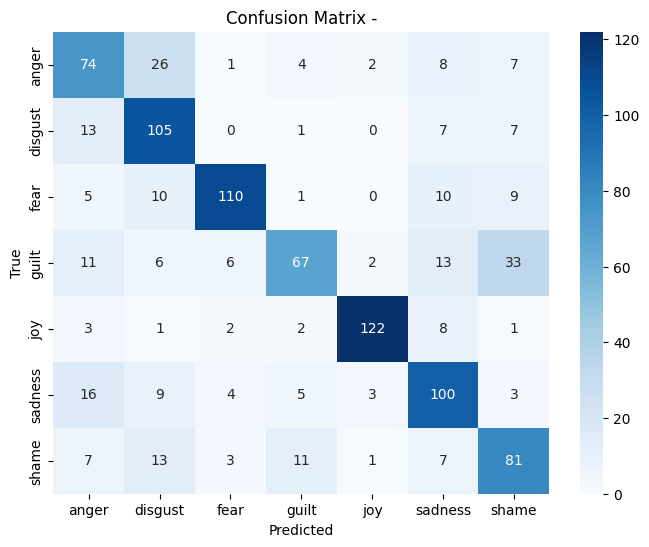

In [31]:
# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix -")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [32]:
# Store results
results = {
    "accuracy": report["accuracy"],
    "f1": report["macro avg"]["f1-score"],
    "weight_f1": report["weighted avg"]["f1-score"],
    "precision": report["macro avg"]["precision"],
    "recall": report["macro avg"]["recall"],
}


In [33]:
results

{'accuracy': 0.701063829787234,
 'f1': 0.6975664450029209,
 'weight_f1': 0.7018084453960854,
 'precision': 0.7095849248236578,
 'recall': 0.698668448381411}